# Machine Learning Safety 
## (Exercise Sheet 6)
### Name: Preetham Louis
### Matriculation Number: 261326

Installing Grad-CAM

In [1]:
!pip3 install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 17.5 MB/s  0:00:00 eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 19.0 MB/s  0:00:02 eta 0:00:01
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=bc59684106859f86563c396eda5340d66f4402d1dcb17fbed13f470fd4762f3b
  Stored in directory: /Users/maverick/Library/Caches/pip/wheels/78/3c/2b/7d0b9dee70a45fa1925ad6b2b655086f816fb45c293a53d0d9
Successfully built grad-cam
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [grad-cam]2/4 [opencv-python]


imports

In [66]:
import torch
import torch.nn as nn

from torchvision import models, transforms

from PIL import Image

import matplotlib.pyplot as plt

import numpy as np

import pandas as pd

import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [67]:
!ls

test             test-town-01.zip train.zip
test-fog.zip     test.zip         validation
test-night.zip   train            validation.zip


 Device Configuration and Image Preprocessing

In [68]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)

transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

Loading Trained Models

In [71]:
cd /Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/Trained Models

/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/Trained Models


In [72]:
vehicle_model = models.resnet18(weights=None)
vehicle_model.fc = nn.Linear(vehicle_model.fc.in_features, 1)
vehicle_model.load_state_dict(
    torch.load('vehicle_model.pth', map_location=device)
)
vehicle_model.eval()


pedestrian_model = models.resnet18(weights=None)
pedestrian_model.fc = nn.Linear(pedestrian_model.fc.in_features, 1)
pedestrian_model.load_state_dict(
    torch.load('pedestrian_model.pth', map_location=device)
)
pedestrian_model.eval()


traffic_model = models.resnet18(weights=None)
traffic_model.fc = nn.Linear(traffic_model.fc.in_features, 1)
traffic_model.load_state_dict(
    torch.load('traffic_light_model.pth', map_location=device)
)
traffic_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

Load Test Labels

In [73]:
cd /Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets

/Users/maverick/Documents/Notes/Machine Learning Safety/ML Safety Files/ML safety 2026 datasets


In [74]:
labels = pd.read_csv(
    'test/labels.csv'
)

labels.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249


Find Vehicle Images

In [75]:
vehicle_images = labels[
    labels['has_vehicle'] == True
]

vehicle_images.head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249
5,50,True,False,True,297,0,248


# 5 Correct Classifications

## Vehicle Model - Correct Example 1

In [157]:
img_path = 'test/rgb-front/000010.jpg'

Loads the image for visualization.

Grad-CAM overlay needs: rgb_img

In [158]:
rgb_img = cv2.imread(img_path)

rgb_img = cv2.cvtColor(
    rgb_img,
    cv2.COLOR_BGR2RGB
)

rgb_img = np.float32(rgb_img) / 255.0

Loads the same image for the model.

input_tensor: Resnet18 uses this for model prediction 

In [159]:
input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)

### Generate Grad-CAM Heatmap

In [160]:
target_layers = [vehicle_model.layer4[-1]]
cam = GradCAM(
    model=vehicle_model,
    target_layers=target_layers
)
grayscale_cam = cam(
    input_tensor=input_tensor
)[0]
rgb_img_resized = cv2.resize(
    rgb_img,
    (224,224)
)
visualization = show_cam_on_image(
    rgb_img_resized,
    grayscale_cam,
    use_rgb=True
)

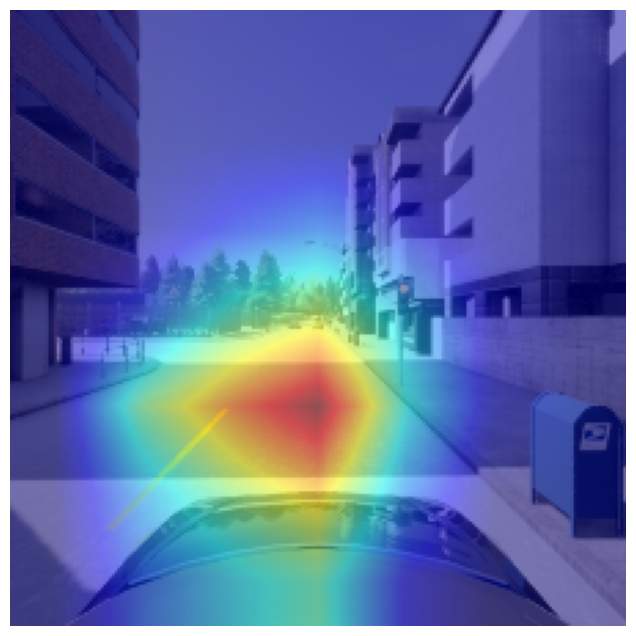

In [161]:
plt.figure(figsize=(8,8))

plt.imshow(visualization)

plt.axis('off')

plt.show()

### Verify Prediction

In [86]:
vehicle_model = vehicle_model.to(device)

In [87]:
with torch.no_grad():

    output = vehicle_model(
        input_tensor.to(device)
    )

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).float()

print("Probability:", prob.item())

print("Prediction:", pred.item())

Probability: 0.9996976852416992
Prediction: 1.0


### Ground Truth Label

In [88]:
labels[
    labels['frame'] == frame
]

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
1,10,True,False,True,299,0,116


## Check for Saliency Map

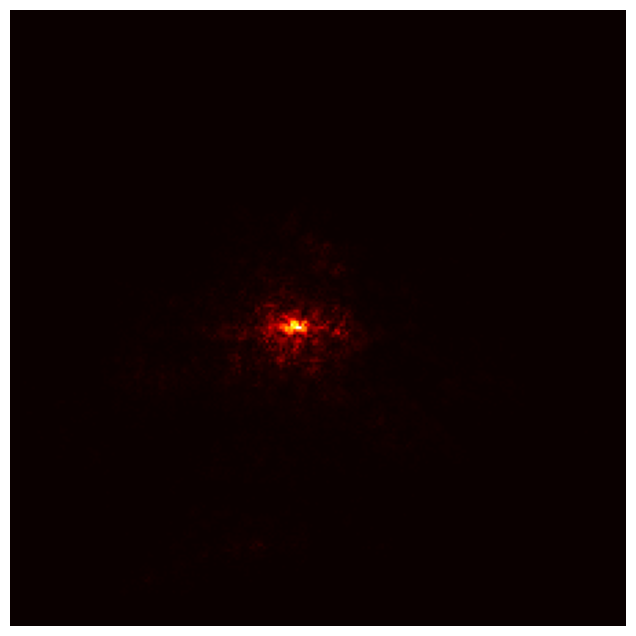

In [162]:
input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0).to(device)

input_tensor.requires_grad = True

output = vehicle_model(input_tensor)

output.backward()

saliency = input_tensor.grad.data.abs()

saliency, _ = saliency.max(dim=1)

saliency = saliency.squeeze().cpu().numpy()

plt.figure(figsize=(8,8))

plt.imshow(saliency, cmap='hot')

plt.axis('off')

plt.show()

## Vehicle Model - Correct Example 2

In [91]:
img_path = 'test/rgb-front/000020.jpg'

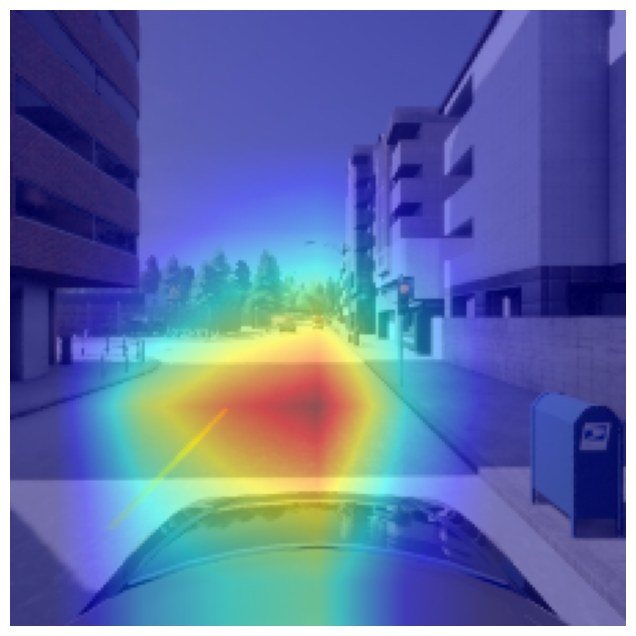

Probability: 0.9999790191650391
Prediction: 1.0


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
1,10,True,False,True,299,0,116


In [93]:
rgb_img = cv2.imread(img_path)

rgb_img = cv2.cvtColor(
    rgb_img,
    cv2.COLOR_BGR2RGB
)

rgb_img = np.float32(rgb_img) / 255.0

input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)

target_layers = [vehicle_model.layer4[-1]]

cam = GradCAM(
    model=vehicle_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

rgb_img_resized = cv2.resize(
    rgb_img,
    (224,224)
)

visualization = show_cam_on_image(
    rgb_img_resized,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))

plt.imshow(visualization)

plt.axis('off')

plt.show()

with torch.no_grad():

    output = vehicle_model(input_tensor.to(device))

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).float()

print("Probability:", prob.item())

print("Prediction:", pred.item())

labels = pd.read_csv('test/labels.csv')

labels[labels['frame'] == 10]

## Pedestrian Model - Correct Example 1

In [94]:
labels[
    labels['has_pedestrian'] == True
].head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
105,1050,True,True,False,337,67,21
106,1060,True,True,True,337,81,43
119,1190,True,True,True,179,80,1897
120,1200,False,True,True,34,80,4297
121,1210,True,True,True,81,158,3440


In [99]:
img_path = 'test/rgb-front/001050.jpg'

In [97]:
pedestrian_model = pedestrian_model.to(device)

verify frame 1050

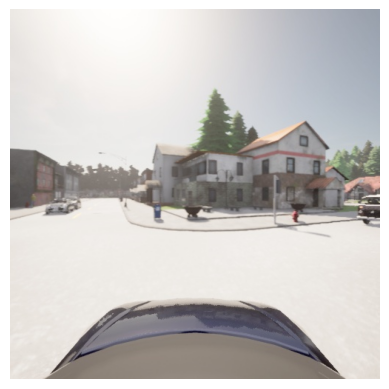

In [105]:
img_path = 'test/rgb-front/001190.jpg'

rgb_img = cv2.imread(img_path)

input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)

plt.imshow(cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

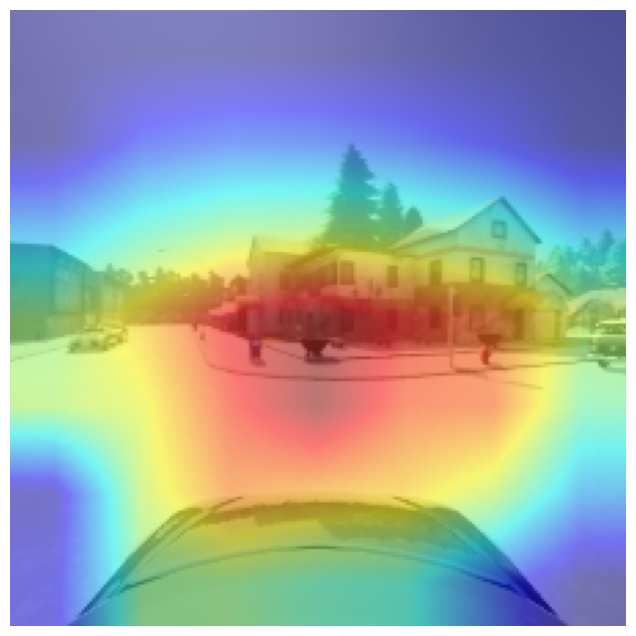

Probability: 0.9243437647819519
Prediction: 1.0


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
119,1190,True,True,True,179,80,1897


In [106]:
rgb_img = cv2.imread(img_path)

rgb_img = cv2.cvtColor(
    rgb_img,
    cv2.COLOR_BGR2RGB
)

rgb_img = np.float32(rgb_img) / 255.0

input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)


target_layers = [pedestrian_model.layer4[-1]]


cam = GradCAM(
    model=pedestrian_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

rgb_img_resized = cv2.resize(
    rgb_img,
    (224,224)
)

visualization = show_cam_on_image(
    rgb_img_resized,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))

plt.imshow(visualization)

plt.axis('off')

plt.show()

with torch.no_grad():

    output = pedestrian_model(input_tensor.to(device))

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).float()

print("Probability:", prob.item())

print("Prediction:", pred.item())

labels = pd.read_csv('test/labels.csv')

frame = 1190

labels[labels['frame'] == frame]

## Pedestrian Model - Correct Example 2

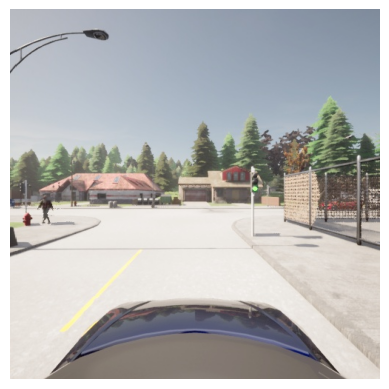

In [163]:
img_path = 'test/rgb-front/001300.jpg'

rgb_img = cv2.imread(img_path)

input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)

plt.imshow(cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

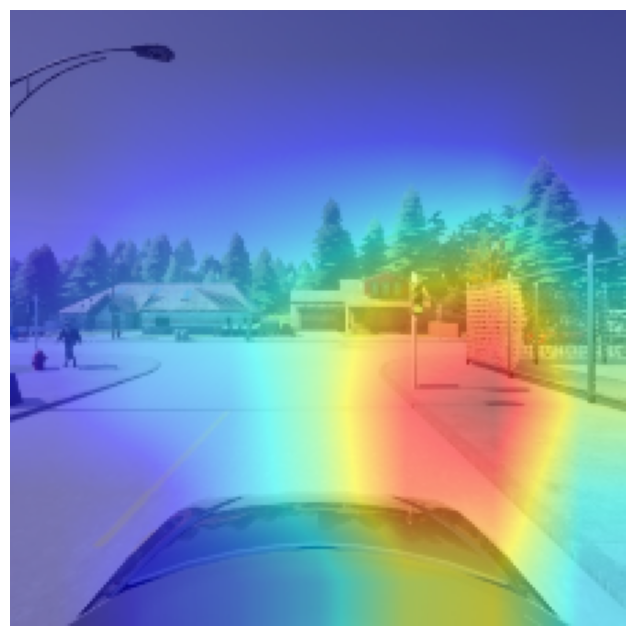

Probability: 0.9674994349479675
Prediction: 1.0


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
130,1300,True,True,False,442,372,4


In [164]:
rgb_img = cv2.imread(img_path)

rgb_img = cv2.cvtColor(
    rgb_img,
    cv2.COLOR_BGR2RGB
)

rgb_img = np.float32(rgb_img) / 255.0

input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)


target_layers = [pedestrian_model.layer4[-1]]


cam = GradCAM(
    model=pedestrian_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

rgb_img_resized = cv2.resize(
    rgb_img,
    (224,224)
)

visualization = show_cam_on_image(
    rgb_img_resized,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))

plt.imshow(visualization)

plt.axis('off')

plt.show()

with torch.no_grad():

    output = pedestrian_model(input_tensor.to(device))

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).float()

print("Probability:", prob.item())

print("Prediction:", pred.item())

labels = pd.read_csv('test/labels.csv')

frame = 1300

labels[labels['frame'] == frame]

## check with Saliency Map

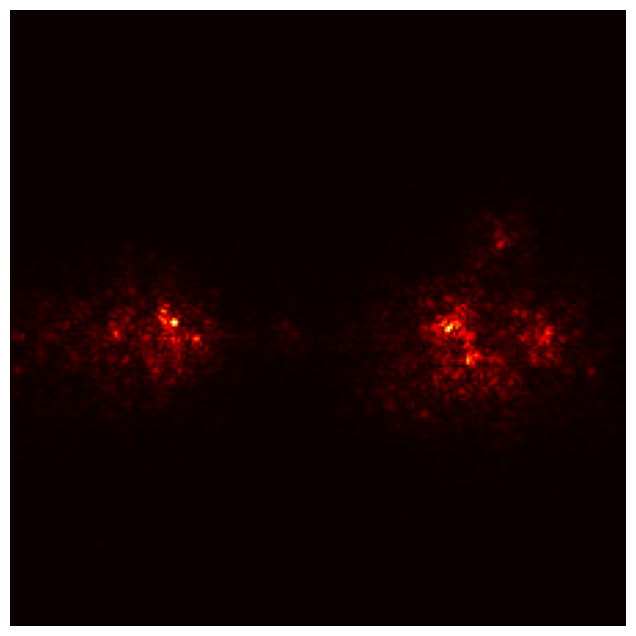

Probability: 0.9674994349479675
Prediction: 1.0


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
130,1300,True,True,False,442,372,4


In [165]:
input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0).to(device)

input_tensor.requires_grad = True

output = pedestrian_model(input_tensor)

score = output.squeeze()

pedestrian_model.zero_grad()

score.backward()

saliency = input_tensor.grad.abs()

saliency, _ = saliency.max(dim=1)

saliency = saliency.squeeze().cpu().numpy()

plt.figure(figsize=(8,8))

plt.imshow(saliency, cmap='hot')

plt.axis('off')

plt.show()

with torch.no_grad():

    output = pedestrian_model(input_tensor)

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).float()

print("Probability:", prob.item())

print("Prediction:", pred.item())

labels = pd.read_csv('test/labels.csv')

frame = 1300

labels[labels['frame'] == frame]

## Traffic light Model - Correct Example 1

In [114]:
labels[
    labels['has_traffic_light'] == True
].head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249
5,50,True,False,True,297,0,248


In [115]:
img_path = 'test/rgb-front/000010.jpg'

In [118]:
traffic_model = traffic_model.to(device)

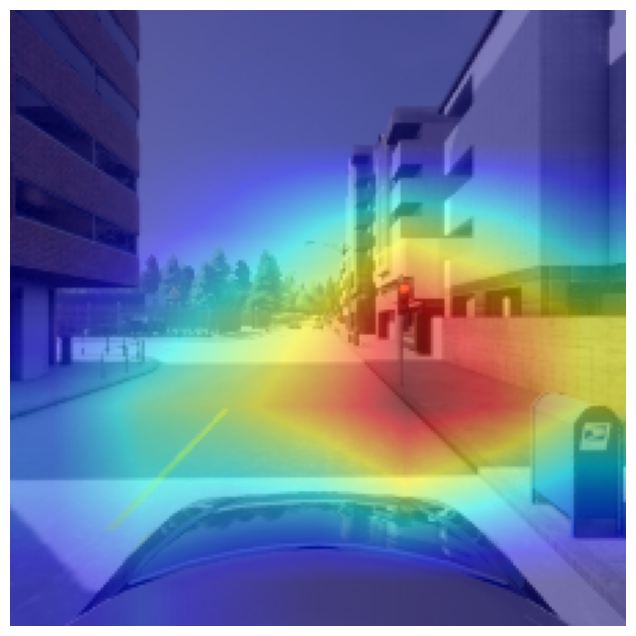

Probability: 0.999958872795105
Prediction: 1.0


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
130,1300,True,True,False,442,372,4


In [119]:
rgb_img = cv2.imread(img_path)

rgb_img = cv2.cvtColor(
    rgb_img,
    cv2.COLOR_BGR2RGB
)

rgb_img = np.float32(rgb_img) / 255.0

input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)


target_layers = [traffic_model.layer4[-1]]


cam = GradCAM(
    model=traffic_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

rgb_img_resized = cv2.resize(
    rgb_img,
    (224,224)
)

visualization = show_cam_on_image(
    rgb_img_resized,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))

plt.imshow(visualization)

plt.axis('off')

plt.show()

with torch.no_grad():

    output = traffic_model(input_tensor.to(device))

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).float()

print("Probability:", prob.item())

print("Prediction:", pred.item())

labels = pd.read_csv('test/labels.csv')

frame = 1300

labels[labels['frame'] == frame]

# 3 Misclassifications

## pedestrian model

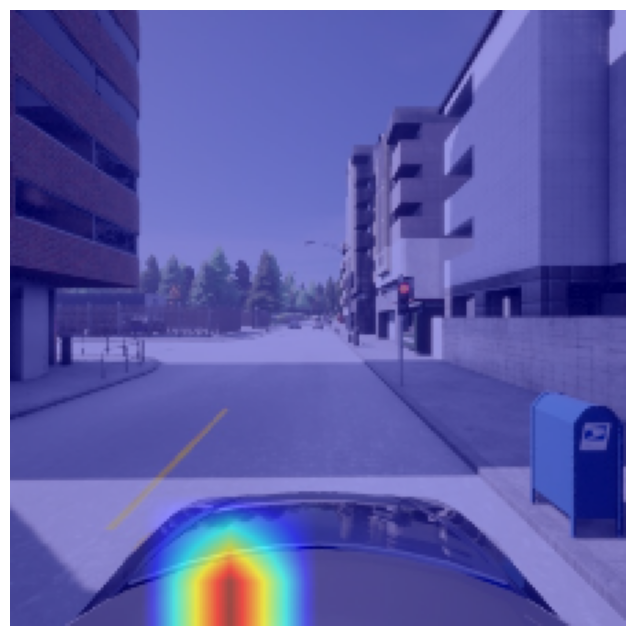

Probability: 0.0002404380647931248
Prediction: 0.0


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
105,1050,True,True,False,337,67,21


In [120]:
rgb_img = cv2.imread(img_path)

rgb_img = cv2.cvtColor(
    rgb_img,
    cv2.COLOR_BGR2RGB
)

rgb_img = np.float32(rgb_img) / 255.0

input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)


target_layers = [pedestrian_model.layer4[-1]]


cam = GradCAM(
    model=pedestrian_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

rgb_img_resized = cv2.resize(
    rgb_img,
    (224,224)
)

visualization = show_cam_on_image(
    rgb_img_resized,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))

plt.imshow(visualization)

plt.axis('off')

plt.show()

with torch.no_grad():

    output = pedestrian_model(input_tensor.to(device))

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).float()

print("Probability:", prob.item())

print("Prediction:", pred.item())

labels = pd.read_csv('test/labels.csv')

frame = 1050

labels[labels['frame'] == frame]

## Traffic Light Model

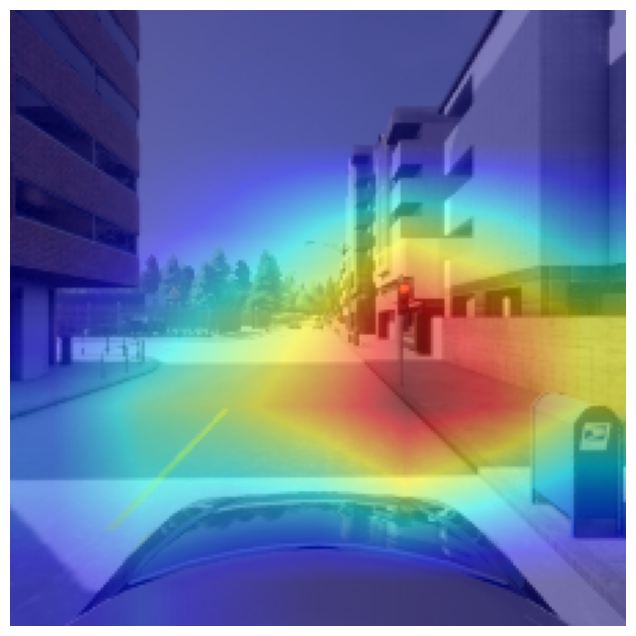

Probability: 0.999958872795105
Prediction: 1.0


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
120,1200,False,True,True,34,80,4297


In [122]:
rgb_img = cv2.imread(img_path)

rgb_img = cv2.cvtColor(
    rgb_img,
    cv2.COLOR_BGR2RGB
)

rgb_img = np.float32(rgb_img) / 255.0

input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)


target_layers = [traffic_model.layer4[-1]]


cam = GradCAM(
    model=traffic_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

rgb_img_resized = cv2.resize(
    rgb_img,
    (224,224)
)

visualization = show_cam_on_image(
    rgb_img_resized,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))

plt.imshow(visualization)

plt.axis('off')

plt.show()

with torch.no_grad():

    output = traffic_model(input_tensor.to(device))

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).float()

print("Probability:", prob.item())

print("Prediction:", pred.item())

labels = pd.read_csv('test/labels.csv')

frame = 1200

labels[labels['frame'] == frame]

## Vehicle Model

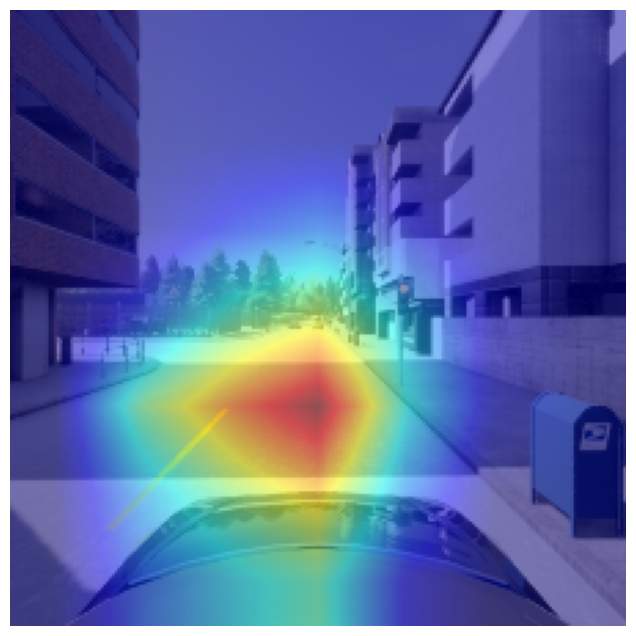

Probability: 0.9996976852416992
Prediction: 1.0


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
20,200,True,False,False,358,0,32


In [127]:
rgb_img = cv2.imread(img_path)

rgb_img = cv2.cvtColor(
    rgb_img,
    cv2.COLOR_BGR2RGB
)

rgb_img = np.float32(rgb_img) / 255.0

input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)

target_layers = [vehicle_model.layer4[-1]]

cam = GradCAM(
    model=vehicle_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

rgb_img_resized = cv2.resize(
    rgb_img,
    (224,224)
)

visualization = show_cam_on_image(
    rgb_img_resized,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))

plt.imshow(visualization)

plt.axis('off')

plt.show()

with torch.no_grad():

    output = vehicle_model(input_tensor.to(device))

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).float()

print("Probability:", prob.item())

print("Prediction:", pred.item())

labels = pd.read_csv('test/labels.csv')

labels[labels['frame'] == 200]

## Test for Different Conditions

### Night-Pedestrian detection

In [128]:
labels = pd.read_csv('test-night/labels.csv')

labels[
    labels['has_pedestrian'] == True
].head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
105,1050,True,True,False,337,67,21
106,1060,True,True,True,337,81,43
119,1190,True,True,True,179,80,1897
120,1200,False,True,True,34,80,4297
121,1210,True,True,True,81,158,3440


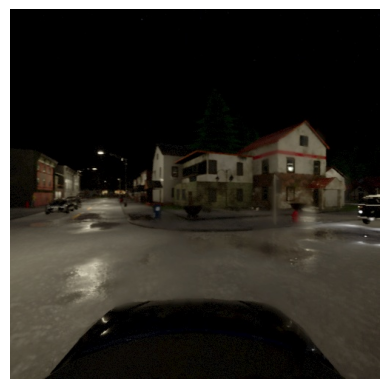

In [142]:
img_path = 'test-night/rgb-front/001190.jpg'
plt.imshow(
    Image.open(img_path)
)
plt.axis('off')
plt.show()

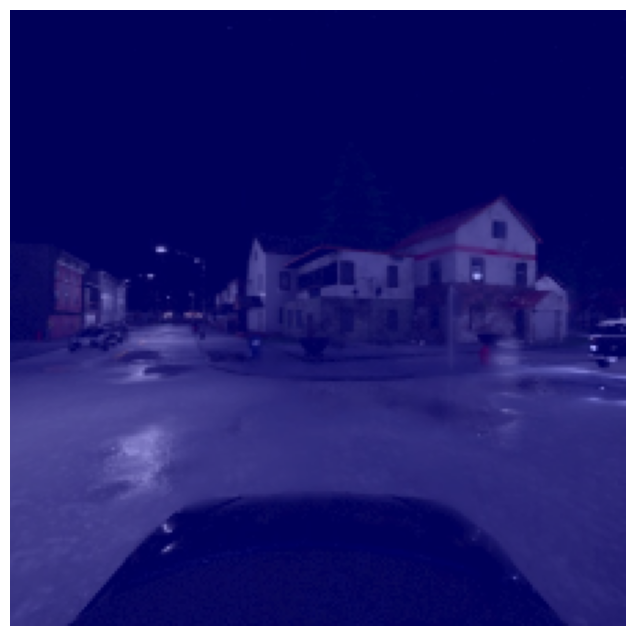

Probability: 0.02930183708667755
Prediction: 0.0


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
119,1190,True,True,True,179,80,1897


In [143]:
rgb_img = cv2.imread(img_path)

rgb_img = cv2.cvtColor(
    rgb_img,
    cv2.COLOR_BGR2RGB
)

rgb_img = np.float32(rgb_img) / 255.0

input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)


target_layers = [pedestrian_model.layer4[-1]]


cam = GradCAM(
    model=pedestrian_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

rgb_img_resized = cv2.resize(
    rgb_img,
    (224,224)
)

visualization = show_cam_on_image(
    rgb_img_resized,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))

plt.imshow(visualization)

plt.axis('off')

plt.show()

with torch.no_grad():

    output = pedestrian_model(input_tensor.to(device))

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).float()

print("Probability:", prob.item())

print("Prediction:", pred.item())

labels = pd.read_csv('test-night/labels.csv')

frame = 1190

labels[labels['frame'] == frame]

Ground Truth = True | 
Prediction = 0 |
Probability = 0.03 |

Heatmap almost disappears.

No clear focus on pedestrian.

### Fog-Pedestrian detection

In [144]:
labels = pd.read_csv('test-fog/labels.csv')

labels[
    labels['has_pedestrian'] == True
].head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
105,1050,True,True,False,337,67,21
106,1060,True,True,True,337,81,43
119,1190,True,True,True,179,80,1897
120,1200,False,True,True,34,80,4297
121,1210,True,True,True,81,158,3440


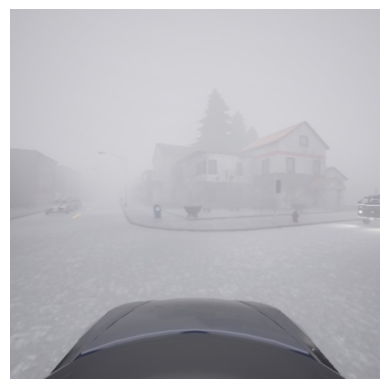

In [146]:
img_path = 'test-fog/rgb-front/001190.jpg'
plt.imshow(
    Image.open(img_path)
)
plt.axis('off')
plt.show()

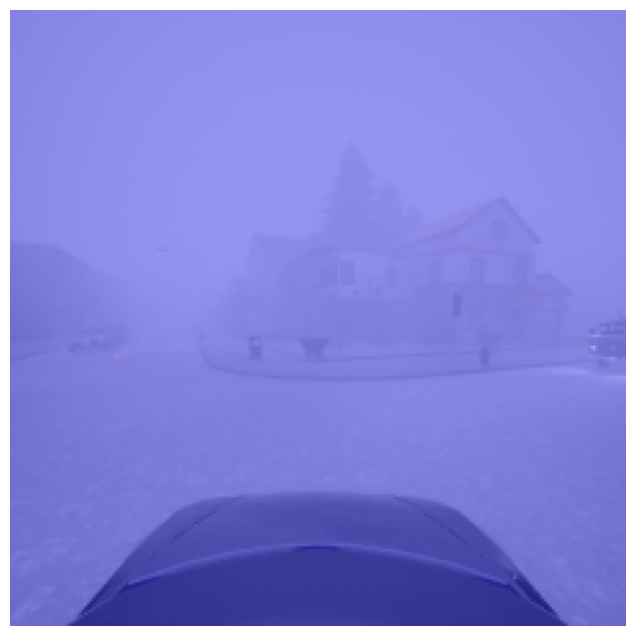

Probability: 0.03714084252715111
Prediction: 0.0


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
119,1190,True,True,True,179,80,1897


In [147]:
rgb_img = cv2.imread(img_path)

rgb_img = cv2.cvtColor(
    rgb_img,
    cv2.COLOR_BGR2RGB
)

rgb_img = np.float32(rgb_img) / 255.0

input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)


target_layers = [pedestrian_model.layer4[-1]]


cam = GradCAM(
    model=pedestrian_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

rgb_img_resized = cv2.resize(
    rgb_img,
    (224,224)
)

visualization = show_cam_on_image(
    rgb_img_resized,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))

plt.imshow(visualization)

plt.axis('off')

plt.show()

with torch.no_grad():

    output = pedestrian_model(input_tensor.to(device))

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).float()

print("Probability:", prob.item())

print("Prediction:", pred.item())

labels = pd.read_csv('test-fog/labels.csv')

frame = 1190

labels[labels['frame'] == frame]

Heatmap is extremely weak and diffuse.

Model seems confused by fog.

### Different-Town-Pedestrian detection

In [152]:
labels = pd.read_csv('test-town-01/labels.csv')

labels[
    labels['has_pedestrian'] == True
].head()

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
15,150,False,True,True,28,42,658
197,1970,False,True,False,1,53,8
198,1980,False,True,False,4,100,9
199,1990,False,True,False,5,191,0
202,2020,False,True,False,5,40,27


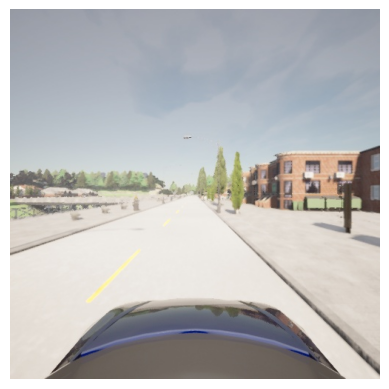

In [154]:
img_path = 'test-town-01/rgb-front/002020.jpg'
plt.imshow(
    Image.open(img_path)
)
plt.axis('off')
plt.show()

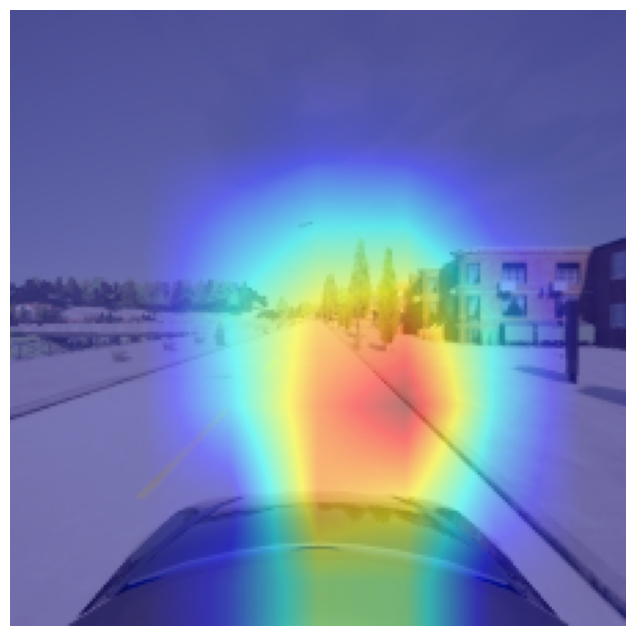

Probability: 0.4219608008861542
Prediction: 0.0


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
202,2020,False,True,False,5,40,27


In [155]:
rgb_img = cv2.imread(img_path)

rgb_img = cv2.cvtColor(
    rgb_img,
    cv2.COLOR_BGR2RGB
)

rgb_img = np.float32(rgb_img) / 255.0

input_tensor = transform(
    Image.open(img_path).convert("RGB")
).unsqueeze(0)


target_layers = [pedestrian_model.layer4[-1]]


cam = GradCAM(
    model=pedestrian_model,
    target_layers=target_layers
)

grayscale_cam = cam(
    input_tensor=input_tensor
)[0]

rgb_img_resized = cv2.resize(
    rgb_img,
    (224,224)
)

visualization = show_cam_on_image(
    rgb_img_resized,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8,8))

plt.imshow(visualization)

plt.axis('off')

plt.show()

with torch.no_grad():

    output = pedestrian_model(input_tensor.to(device))

    prob = torch.sigmoid(output)

    pred = (prob > 0.5).float()

print("Probability:", prob.item())

print("Prediction:", pred.item())

labels = pd.read_csv('test-town-01/labels.csv')

frame = 2020

labels[labels['frame'] == frame]

Heatmap focuses on road/intersection area.

Not on the pedestrian.

### So the model struggles in all three conditions, but:

### Worst: Night and Fog

### Less severe: Different Town